# Heart Disease Prediction with Explainable AI and Bias Analysis

## Table of Contents

1. Problem Framing
2. Data Understanding and EDA
3. Data Preparation
4. Baseline Modeling
5. Random Forest
6. XGBoost
7. Model Comparison
8. Hyperparameter Optimization
9. Explainable AI with SHAP
10. Fairness Analysis
11. Limitations
12. Future Work
12. Conclusion

# Problem framing

### Objective

Build a machine learning pipeline to predict heart disease using structured clinical data,
while analyzing model interpretability and potential bias across patient groups.

### Type of problem

- Supervised learning
- Binary classification
- Offline/Batch learning

### Evaluation metric

We are here in a medical setting. Our goal is to detect patients with a heart disease. Therefore, we should make sure that we do not miss any sick patient. We should focus on lowering false negative.
Recall will therefore be our preferred evaluation metric.

We will also look at the following metric:
- recall
- precision
- F1-score
- ROC-AUC
- accuracy, which can be misleading here.

### Constraints

- Small dataset
- Probable imbalanced dataset
- Need for interpretability (medical context)
- Potential bias across patients groups (age, sex)

## Key Components

- Data preprocessing pipeline
- Model training and evaluation
- Explainable AI (SHAP)
- Bias and fairness analysis

# Data understanding and Exploratory Data analysis

## Loading data

In [2]:
import pandas as pd

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets
df = X.copy()
df["target"] = y
df.to_csv("../data/cleveland_heart.csv")

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

## Data understanding


This dataset contains clinical information used to predict the presence of heart disease.
It traces back to 1988 and consists of four databases: Cleveland, Hungary, Switzerland and VA Long Beach .
Additional Information

This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).

The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.

Each row represents a patient, and each column corresponds to a clinical feature.
The dataset includes both numerical and categorical variables.
It also contains missing values.

You can find the original data source here: https://archive.ics.uci.edu/dataset/45/heart+disease

### Feature description

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


1. age: age in years
2. sex:  sex (1 = male; 0 = female)
3. cp: chest paint type (1: typical angina; 2: atypical angina; 3: non-anginal pain; 4: asymptomatic)
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7. restecg: resting electrocardiographic results (0: normal; 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV); 2: showing probable or definite left ventricular hypertrophy by Estes' criteria)
8. thalach: maximum heart rate achieved
9. exang: exercise induced angina (1 = yes; 0 = no)
10. oldpeak: ST depression induced by exercise relative to rest
11. slope:  slope of the peak exercise ST segment (1: upsloping; 2: flat; 3: downsloping)
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal:  3 = normal; 6 = fixed defect; 7 = reversable defect

### Target description

 Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).
Therefore, we will focus on whether there is a diagnosis of heart disease (angiographic disease status)
        -- Value 0: < 50% diameter narrowing
        -- Value 1: > 50% diameter narrowing

This means that we should replace all non-null values by 1 for the target. This way, our problem can be correctly framed as a binary classification problem

In [6]:
df["target"] = (df["target"] != 0).astype(int)

### Initial observations

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


We have here 303 samples, which is quite low and could be impacting the performance and reliability of our models. Nonetheless, it is not uncommon in a clinical setting where such data is scarce.

From the two outputs of the two cells above, we can already make some preliminary remarks.

First, some features are implemented as numerical features, more precisely with an integer type, but they should still be seen as categorical features. We could leave them this way, since they already encoded. Nonetheless, we could choose another type of encoding, since label encoding could be misleading. We need to keep in mind this distinction for the data preprocessing step

Categorical features are: sex, cp,fbs, restecg, exang, slope, thal.

Furthermore, when looking at the distribution of numerical features, we can see that the value range can be very different across features. This could mean that we need to scale them prior to training some algorithms. We also need to see how skewed their distribution to see if normalization is needed.

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Finally, there are some missing features which we will need to handle. Luckily, the number of missing values is quite low here so it should not be much of a problem.

## Target distribution

In [9]:
df["target"].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

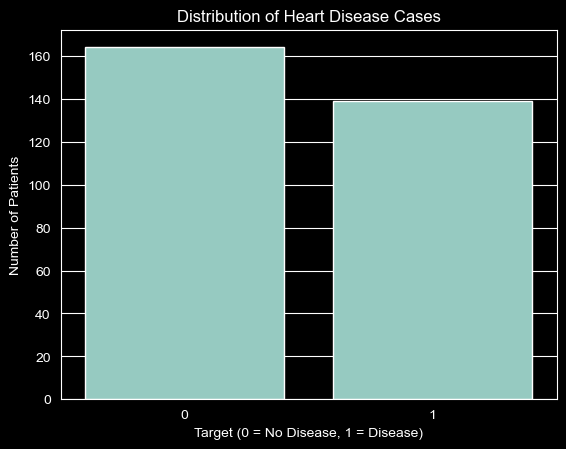

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.show()

To conclude, the dataset is relatively balanced, with approximately 54% of patients having heart disease and 46% not.

This suggests that class imbalance is not a major issue in this dataset.

However, in a healthcare context, recall remains an important metric, as missing positive cases (false negatives) can have serious consequences. Therefore, our choice for the evaluation metric is still relevant.

## Feature distribution

### Numerical features

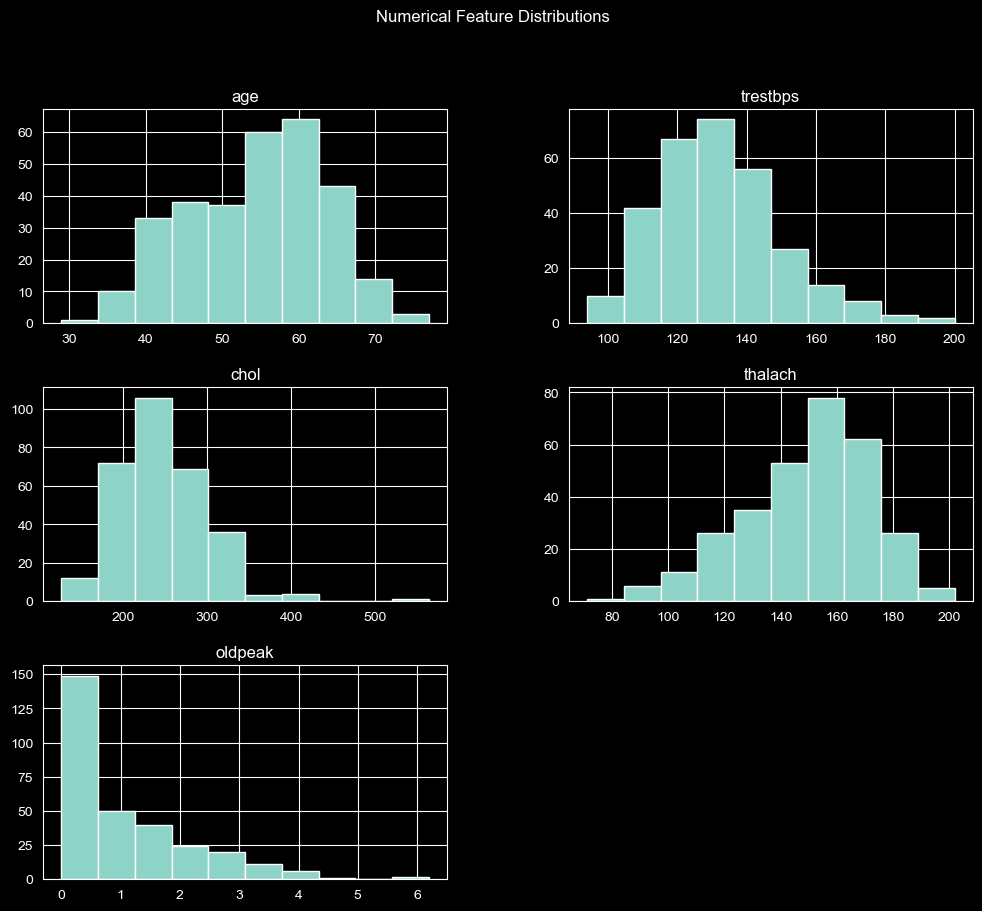

In [11]:
num_cols = ['age','trestbps','chol','thalach','oldpeak']

df[num_cols].hist(figsize=(12,10))
plt.suptitle("Numerical Feature Distributions")
plt.show()

From this quick distribution analysis, we can make the following points:
- some features appear to have a normal distribution (age)
- others are skewed (eg cholesterol)
- there seem to be potential outliers among some features
- they are scaled differently

We need to keep these observations in mind for the preprocessing part (scaling, normalization, transformations).

### Categorical Features

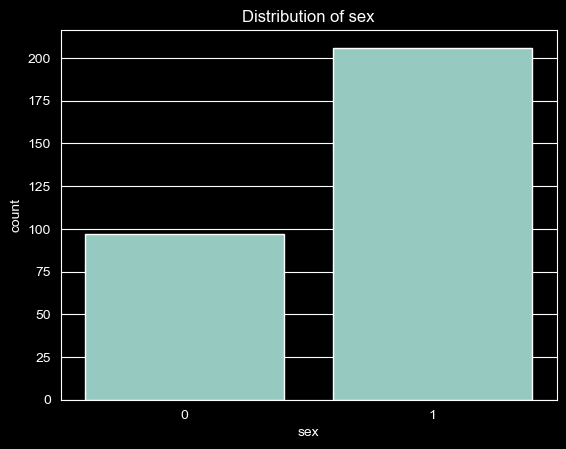

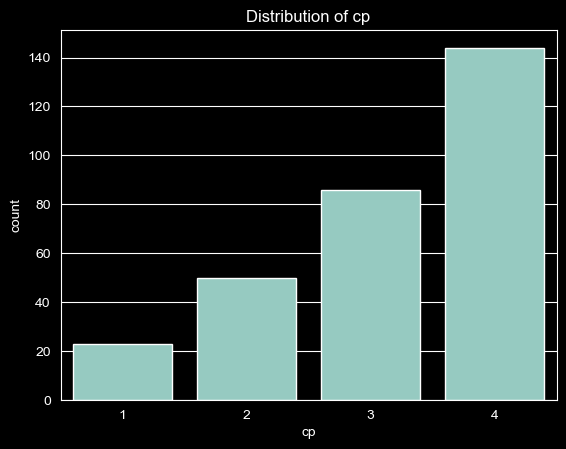

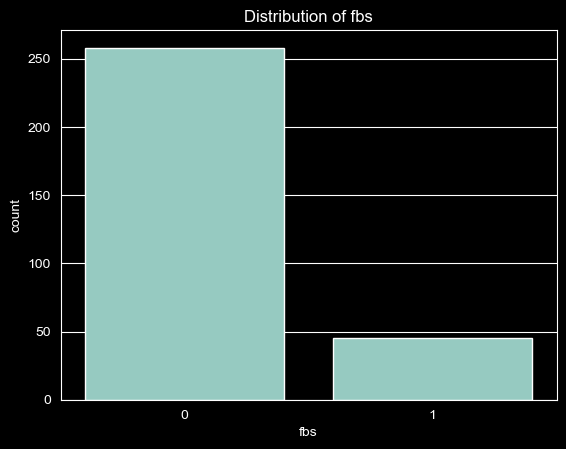

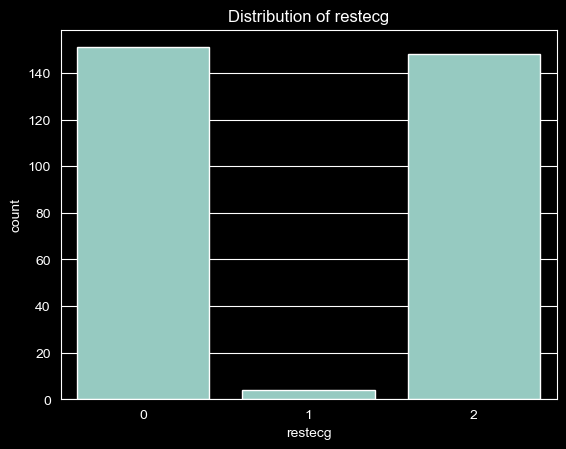

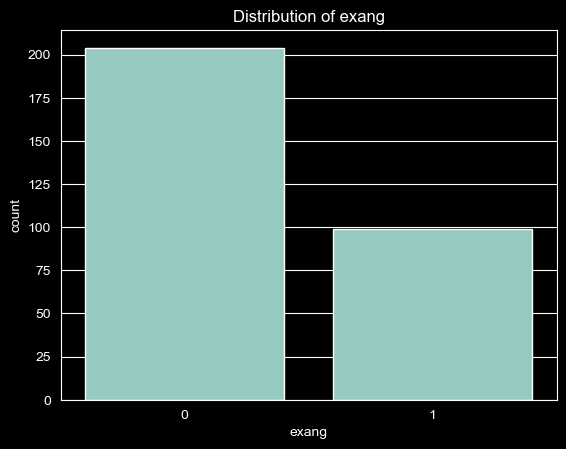

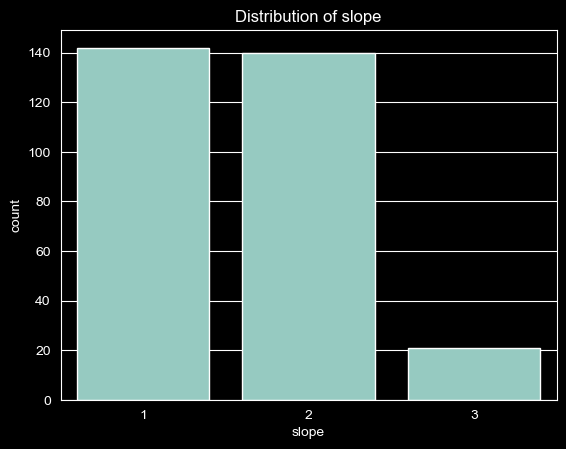

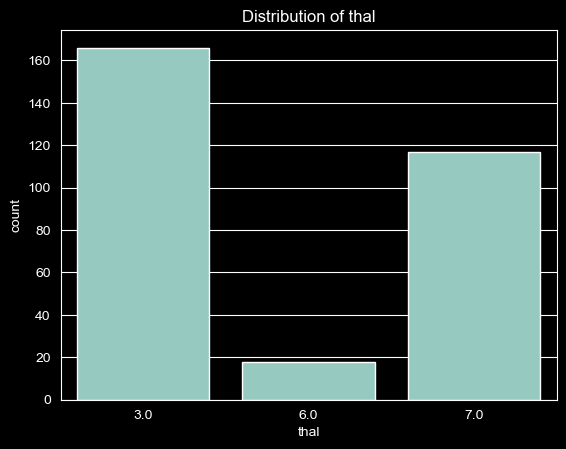


sex proportions:
sex
1    67.99
0    32.01
Name: proportion, dtype: float64

cp proportions:
cp
4    47.52
3    28.38
2    16.50
1     7.59
Name: proportion, dtype: float64

fbs proportions:
fbs
0    85.15
1    14.85
Name: proportion, dtype: float64

restecg proportions:
restecg
0    49.83
2    48.84
1     1.32
Name: proportion, dtype: float64

exang proportions:
exang
0    67.33
1    32.67
Name: proportion, dtype: float64

slope proportions:
slope
1    46.86
2    46.20
3     6.93
Name: proportion, dtype: float64

thal proportions:
thal
3.0    55.15
7.0    38.87
6.0     5.98
Name: proportion, dtype: float64


In [12]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]


for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in cat_cols:
    proportions = df[col].value_counts(normalize=True)
    print(f"\n{col} proportions:")
    print((proportions * 100).round(2))

Categorical feature distributions are briefly examined to ensure sufficient representation across categories.

However, the main focus is on the relationship between these features and the target variable, as this provides more insight into their predictive power.

## Feature vs Target Analysis

We analyze how different features relate to the presence of heart disease
to identify potential predictors.

### Numerical features vs Target

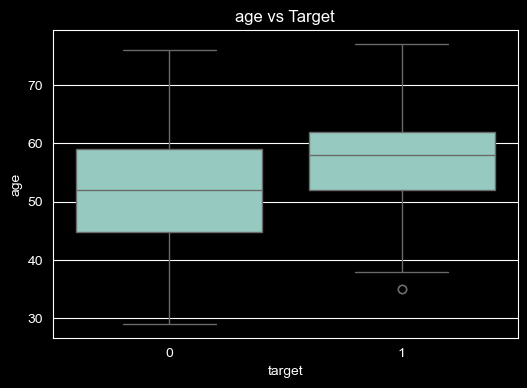

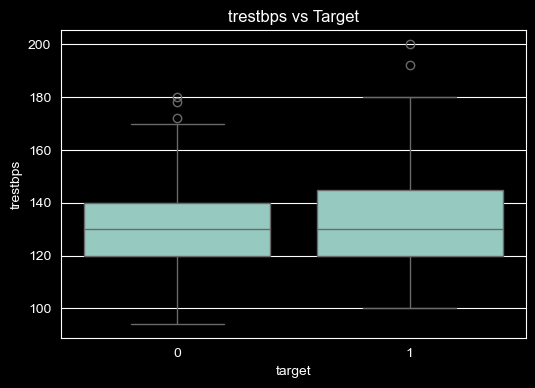

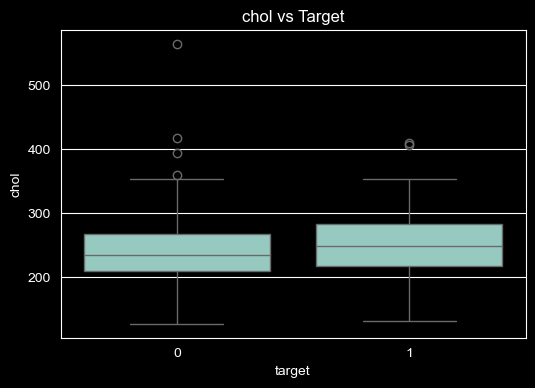

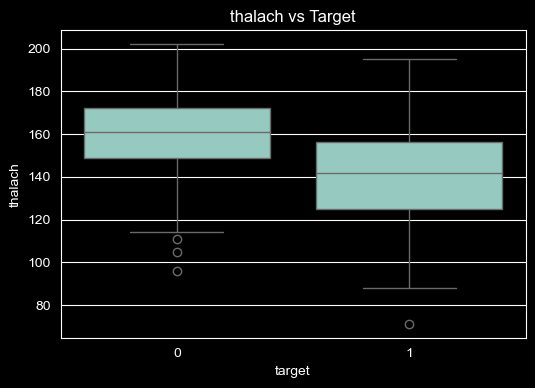

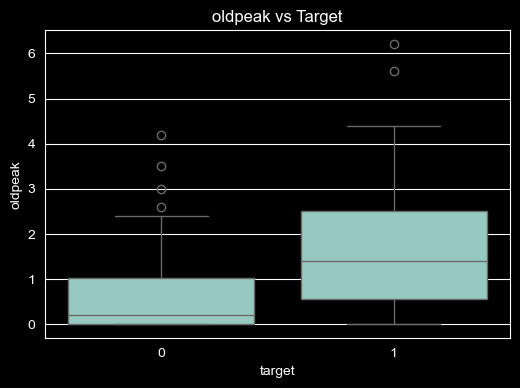

In [13]:

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

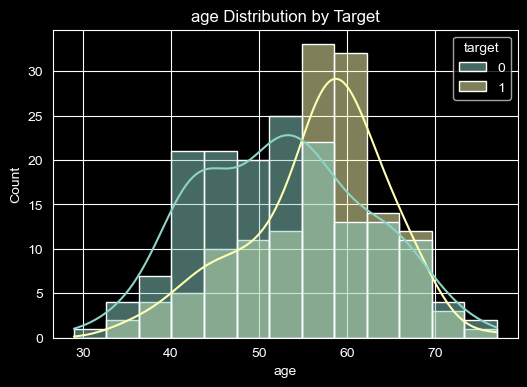

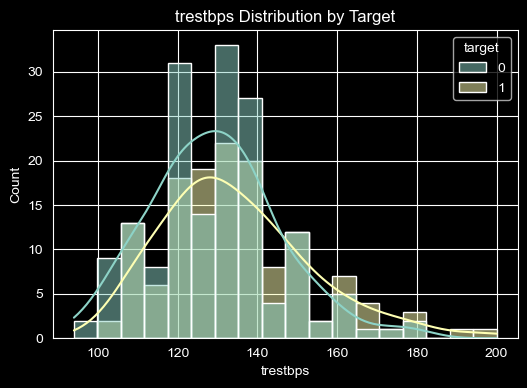

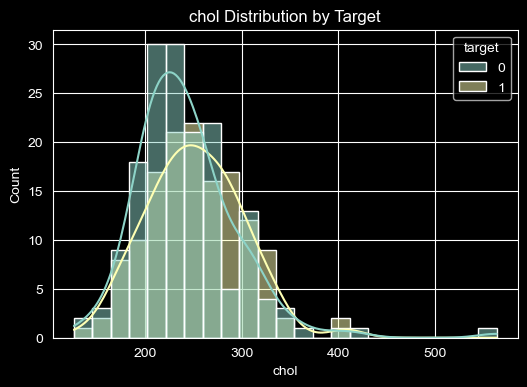

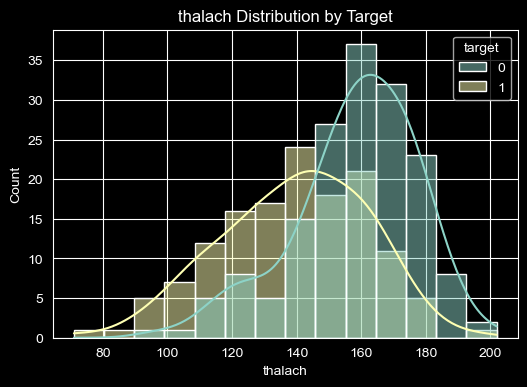

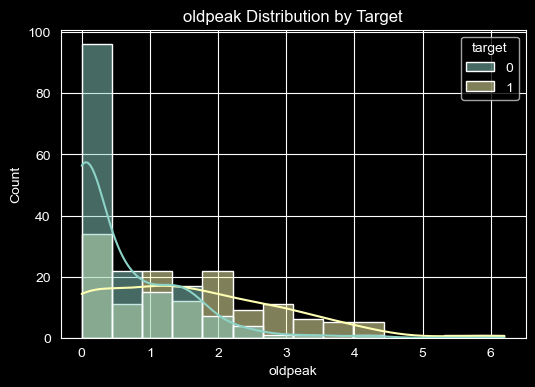

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="target", kde=True)
    plt.title(f"{col} Distribution by Target")
    plt.show()

#### Numerical Feature Insights

Several numerical variables appear to differ between patients with and without heart disease.

- **Age** appears moderately discriminative, with patients diagnosed with heart disease tending to be older on average.

- **Maximum heart rate achieved (`thalach`)** shows noticeable separation between classes, suggesting that lower maximum heart rate may be associated with heart disease.

- **ST depression induced by exercise (`oldpeak`)** also appears informative, with higher values more frequently observed among patients with heart disease.

These observations suggest that these variables may play an important role in predictive modeling.

The observed relationship between exercise-related variables and heart disease is clinically plausible, as cardiovascular conditions can impact exercise tolerance and cardiac response.

### Categorical Features vs Target

We analyze the relationship between categorical clinical variables
and the probability of heart disease.

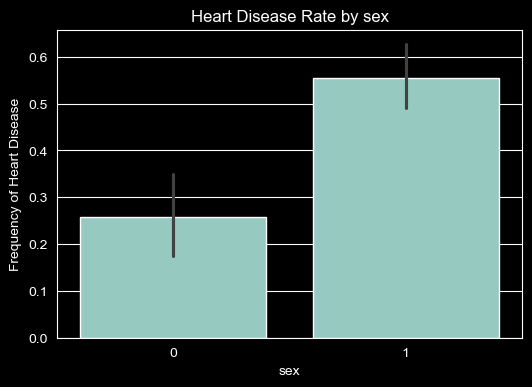

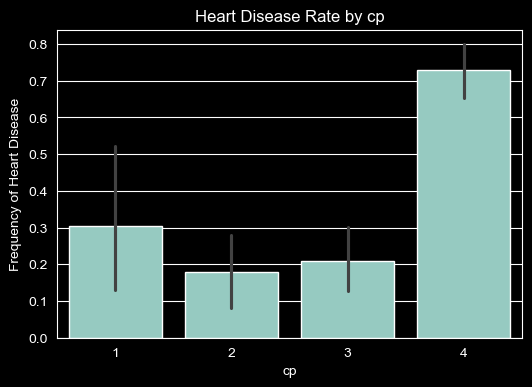

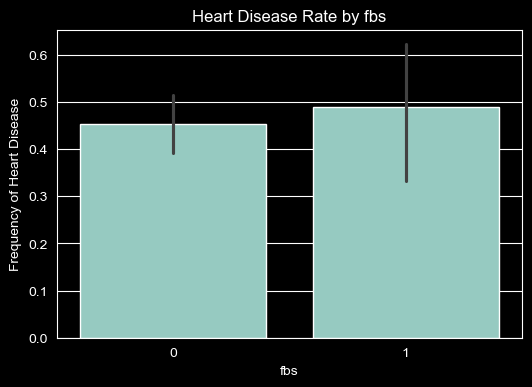

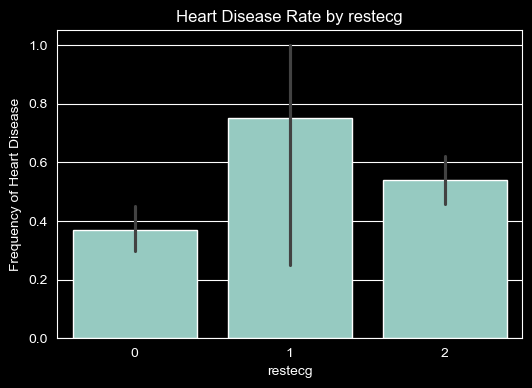

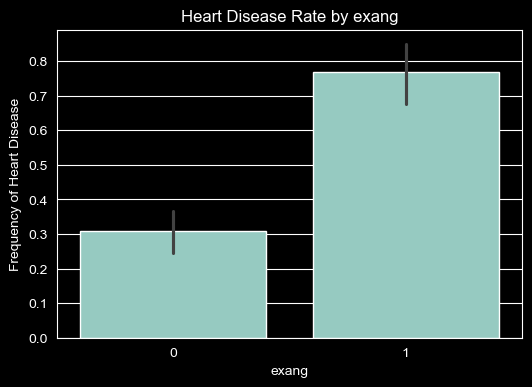

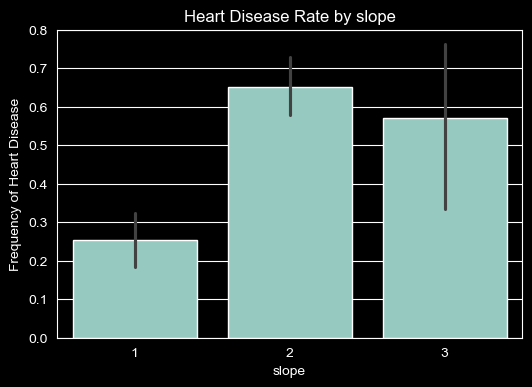

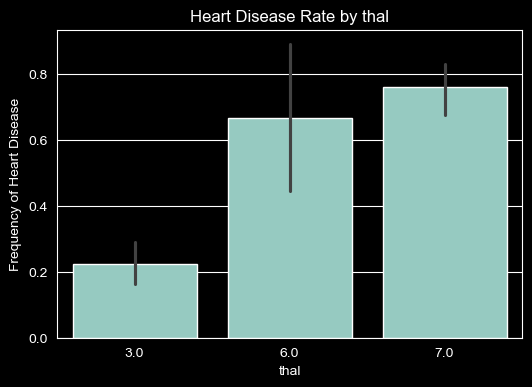

In [15]:
for col in cat_cols:
    plt.figure(figsize=(6,4))

    sns.barplot(x=col, y="target", data=df)

    plt.title(f"Heart Disease Rate by {col}")
    plt.ylabel("Frequency of Heart Disease")

    plt.show()

#### Insights from Categorical Feature Analysis


- **Sex**

Male patients appear significantly more likely to present heart disease in this dataset.

This feature may therefore provide useful predictive information.
However, it also raises fairness considerations that should be explored later in the project.

---

- **Chest Pain Type (`cp`)**

Heart disease prevalence varies substantially across chest pain categories.

Interestingly, the asymptomatic category (`cp = 4`) exhibits the highest prevalence of heart disease in this dataset.

This suggests that the absence of typical chest pain symptoms does not necessarily imply lower cardiovascular risk, highlighting the complexity of clinical diagnosis.

Overall, chest pain type appears to be a highly informative predictive feature.

---

- **Resting ECG Results (`restecg`)**

The relationship between resting ECG results and heart disease appears potentially informative.

However, some categories exhibit large confidence intervals, suggesting limited sample sizes and higher uncertainty in the estimated prevalence rates.

As a result, these observations should be interpreted cautiously.

---

- **Exercise-Induced Angina (`exang`)**

Exercise-induced angina appears strongly associated with heart disease.

Patients exhibiting exercise-induced angina show substantially higher disease prevalence, making this feature potentially highly predictive.

---

- **Fasting Blood Sugar (`fbs`)**

Fasting blood sugar does not appear strongly discriminative in this dataset.

Disease prevalence remains relatively similar across categories, suggesting limited predictive value for this feature alone.

---

- **Thalassemia-Related Feature (`thal`)**

Heart disease prevalence varies considerably across thalassemia-related categories, suggesting that this feature is highly informative.

As with other encoded categorical variables, the categories should be interpreted qualitatively rather than numerically.

---

- **General Observations**

Several categorical variables exhibit substantial differences in disease prevalence across categories, indicating strong predictive potential.

Features such as chest pain type, exercise-induced angina, and thalassemia-related categories appear particularly informative for distinguishing between patients with and without heart disease.

These findings will help guide feature engineering and model development in later stages of the project.

## Correlation Analysis

We analyze correlations between numerical variables and the target
to identify potentially informative features and redundant relationships.

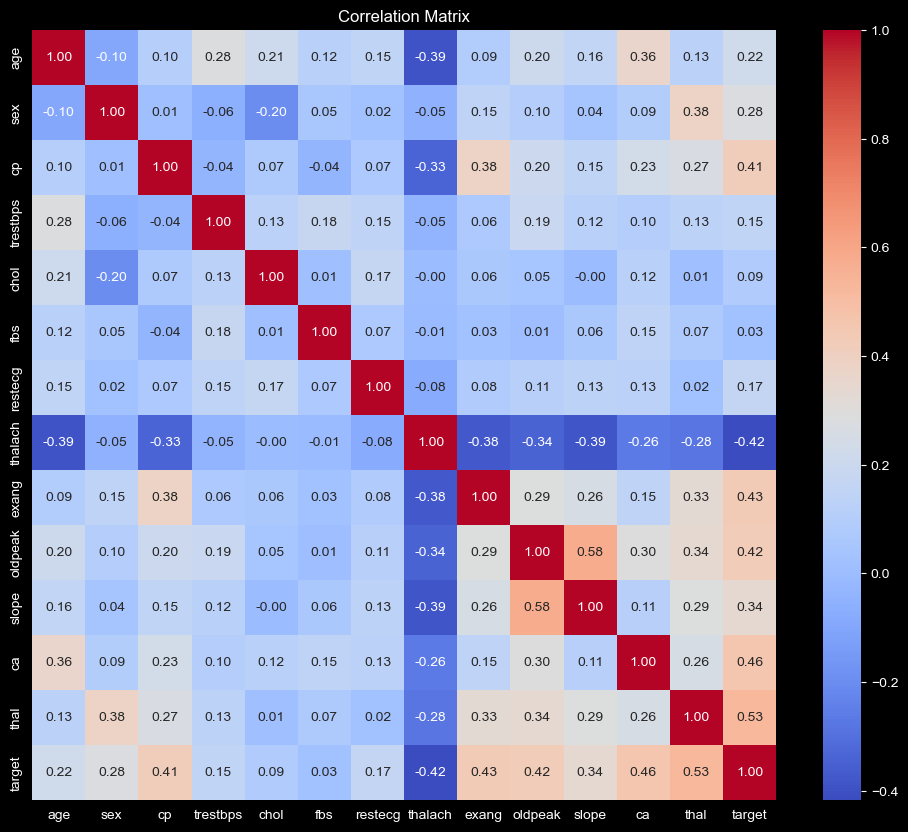

In [16]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Correlation coefficients involving encoded categorical variables should be interpreted cautiously,
as these variables do not represent continuous numerical quantities.

In [17]:
target_corr = corr_matrix["target"].sort_values(ascending=False)


In [18]:
target_corr

target      1.000000
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64

Some encoded categorical variables such as `cp`, `thal`, and `slope`
show strong correlations with the target.

However, these coefficients should be interpreted cautiously,
as the numerical encoding of categories does not imply true ordinal relationships.

### Correlation Insights

Several variables show moderate to strong correlation with heart disease.

In particular:
- `thal` exhibits the strongest positive correlation with the target
- `ca`, `exang`, `oldpeak`, and `cp` also appear highly informative
- `thalach` shows a notable negative correlation, suggesting that lower maximum heart rate is associated with heart disease

The correlation analysis is broadly consistent with previous exploratory analyses.

Several clinically relevant variables, including `thal`, `exang`, `oldpeak`, `cp`, and `thalach`, repeatedly emerge as informative predictors across:
- feature distributions,
- feature-target analyses,
- and correlation analysis.

This consistency strengthens confidence in the relevance of these variables for predictive modeling.

Some feature-feature correlations are also observed, notably between `oldpeak` and `slope`, potentially indicating partial redundancy between related clinical measurements.

However, correlations involving encoded categorical variables such as `cp`, `thal`, and `slope` should be interpreted cautiously, as these variables do not represent continuous numerical quantities.

Many of the strongest predictors are related to exercise response,
cardiac stress, or symptom presentation, which appears clinically coherent
for heart disease prediction.

## Final EDA Summary

The exploratory data analysis revealed several meaningful relationships between clinical variables and the presence of heart disease.

The dataset appears relatively balanced, with comparable proportions of positive and negative cases, reducing concerns related to severe class imbalance. However, because this is a healthcare-related classification problem, metrics such as recall will remain particularly important during model evaluation.

Several numerical variables exhibit informative patterns. In particular:
- `thalach` (maximum heart rate achieved) shows a notable negative relationship with heart disease,
- `oldpeak` (ST depression induced by exercise) appears positively associated with disease presence,
- and age also displays moderate discriminative potential.

Feature-target analyses and correlation analysis consistently identified several highly informative clinical indicators, including:
- `thal`,
- `exang`,
- `oldpeak`,
- `cp`,
- and `thalach`.

This consistency across multiple exploratory approaches strengthens confidence in the predictive relevance of these variables.

Many of the strongest predictors are related to:
- exercise response,
- cardiac stress,
- or symptom presentation,

which appears clinically coherent for heart disease prediction.

Categorical feature analysis also highlighted substantial differences in disease prevalence across patient groups and clinical categories. In particular:
- exercise-induced angina (`exang`) appears strongly associated with disease,
- and asymptomatic chest pain categories (`cp`) show unexpectedly high disease prevalence, illustrating the complexity of cardiovascular diagnosis.

Differences in disease prevalence across demographic groups, particularly sex, were also observed during the analysis. These disparities may reflect population-level clinical patterns, sampling effects, or potential biases within the dataset. Consequently, fairness analysis across demographic groups will be explored during model evaluation.

Some encoded categorical variables such as `cp`, `thal`, and `slope` display strong correlations with the target. However, these coefficients should be interpreted cautiously, as their numerical encoding does not imply true ordinal relationships.

Some categorical feature levels also exhibit relatively large confidence intervals, suggesting limited sample sizes and increased uncertainty in estimated disease prevalence for these groups. As a result, conclusions regarding certain categories should be interpreted cautiously.

Several numerical variables additionally display skewed distributions or potential outliers, which may influence model behavior and motivate the use of preprocessing techniques such as scaling or robust modeling approaches.

Overall, the exploratory analysis suggests that the dataset contains several clinically meaningful and potentially predictive variables suitable for machine learning modeling. The observed feature distributions, group disparities, and feature relationships will guide preprocessing choices and subsequent model development.

# Data Preparation

We build a preprocessing pipeline to:
- handle missing values,
- scale numerical features,
- encode categorical variables,
- and ensure reproducible preprocessing for modeling.

## Data Preparation and Preprocessing Pipeline

In this section, we prepare the dataset for machine learning.

The goal is to build a reproducible preprocessing pipeline that:
- separates features and target,
- splits the data into training and test sets,
- handles numerical and categorical variables appropriately,
- prevents data leakage by fitting preprocessing steps only on the training data.

## Definition of features and target

In [19]:
X = df.drop(columns=["target"])
y = df["target"]

## Definition of numerical and categorical features

In [20]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

## Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

We use stratified sampling during the train-test split to preserve the target class distribution across both datasets.

This helps ensure that the training and test sets remain representative of the original dataset and leads to more reliable model evaluation.

However, stratification is performed only on the target variable and does not guarantee balanced representation across demographic groups such as sex or age categories. Consequently, fairness-related disparities may still exist and will be investigated during the bias analysis stage.

## Building the preprocessing pipelines

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

### Numerical pipeline

In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Numerical variables are imputed using the median rather than the mean, as several features exhibit skewed distributions and potential outliers.

Features are then standardized using `StandardScaler` to ensure comparable scales across variables, which is particularly important for models sensitive to feature magnitude such as Logistic Regression.

Alternative preprocessing strategies such as robust scaling or KNN-based imputation could also be considered, particularly in the presence of strong outliers or more substantial missing data.

### Categorical pipeline

In [24]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Categorical variables are imputed using the most frequent category, as these features represent discrete clinical categories rather than continuous numerical quantities.

Categorical features are then one-hot encoded to avoid introducing artificial ordinal relationships between encoded category values.

This is particularly important for variables such as `cp`, `thal`, and `slope`, whose numerical encodings correspond to clinical subtypes rather than ordered measurements.

The encoder is configured with `handle_unknown="ignore"` to improve robustness when encountering unseen categories during inference.

### Combined preprocessor

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The preprocessing pipeline applies different transformations depending on feature type.

Numerical variables are imputed using the median and standardized to ensure comparable feature scales.

Categorical variables are imputed using the most frequent category and one-hot encoded, since their numerical encodings represent categories rather than continuous quantities.

# Baseline Modeling

We start with Logistic Regression as a simple and interpretable baseline model.

This model will help establish a reference performance before testing more complex models.

Because the dataset is relatively small, we first evaluate the model using cross-validation on the training set. The test set remains untouched and is only used for final evaluation.

## Importing model and metrics

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

## Building the baseline pipeline

In [27]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

## Defining the cross-validation strategy

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

We use stratified 5-fold cross-validation to preserve the target distribution across folds.

This provides a more robust performance estimate than a single validation split.

## Cross-validated evaluation

In [29]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [30]:
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

accuracy: 0.847 ± 0.010
precision: 0.877 ± 0.054
recall: 0.783 ± 0.046
f1: 0.825 ± 0.007
roc_auc: 0.902 ± 0.014


Cross-validation results are reported as mean ± standard deviation across folds.

The standard deviation indicates how stable the model performance is across different validation splits.

## Fitting baseline on the full training dataset

In [31]:
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Prediction on test set

In [32]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

## Evaluation on the test set

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [34]:
test_roc_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {test_roc_auc:.3f}")

Test ROC-AUC: 0.966


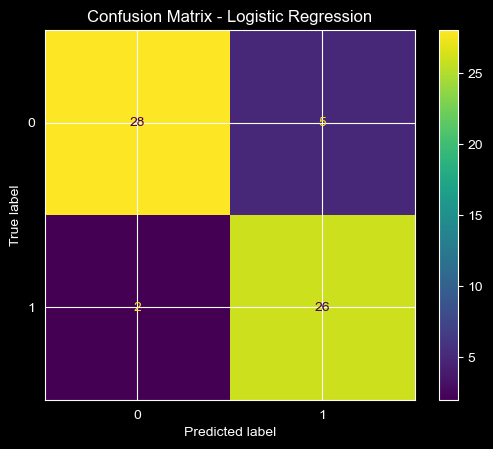

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

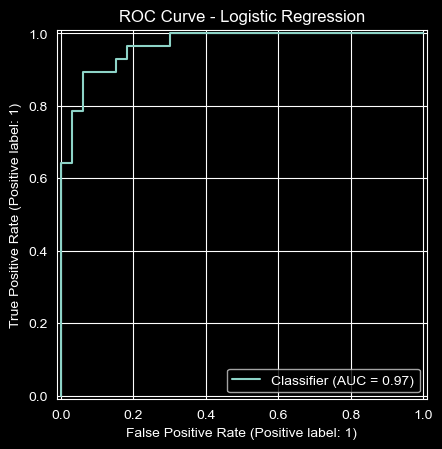

In [36]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

## Baseline Model Interpretation

Logistic Regression provides a simple and interpretable baseline for this binary classification task.

Cross-validation gives a more robust estimate of model performance than a single split, while the final test set provides an estimate of generalization on unseen data.

In this healthcare context, recall for the positive class is particularly important, as false negatives correspond to patients with heart disease who are incorrectly classified as not having the condition.

ROC-AUC is also useful because it evaluates the model's ability to distinguish between patients with and without heart disease across different classification thresholds.

## Baseline Model Summary

A Logistic Regression model was used as an interpretable baseline classifier for the heart disease prediction task.

To obtain a robust estimate of model performance, stratified 5-fold cross-validation was applied on the training set before evaluating the final model on a held-out test set.

The baseline model achieved strong overall performance, with approximately 89% accuracy on the test set. Performance remained balanced across both classes, suggesting that the preprocessing pipeline and selected features provide meaningful predictive information.

Most importantly, the model achieved a recall of 93% for patients with heart disease, indicating that the vast majority of positive cases were correctly identified. This is particularly important in a healthcare context, where false negatives may have significant clinical consequences.

The confusion matrix further confirmed this observation, with only two false negatives on the test set. The model does produce a small number of false positives, suggesting that it slightly favors sensitivity over specificity — a tradeoff that can be acceptable in medical screening scenarios.

The ROC curve also demonstrated excellent discriminative capability, with an ROC-AUC score of approximately 0.97. This indicates that the model is highly effective at separating patients with and without heart disease across different classification thresholds.

Overall, these results suggest that:
- the dataset contains strong predictive signals,
- the preprocessing pipeline is appropriate,
- and even a relatively simple linear model can achieve strong performance on this task.

However, the relatively small size of the dataset should be considered when interpreting these results. Further evaluation using additional models, explainability techniques, and fairness analysis will therefore be explored in subsequent stages of the project.

# Random Forest Model

The Random Forest model will be evaluated to capture potentially non-linear relationships between clinical variables and heart disease risk.

Compared to Logistic Regression, Random Forests can model more complex interactions between features and are less constrained by linear assumptions.

Performance metrics and ROC-AUC will be compared against the Logistic Regression baseline to assess whether increased model complexity leads to improved predictive performance.

## Importing the model

In [37]:
from sklearn.ensemble import RandomForestClassifier

## Building the Random Forest Pipeline

In [38]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

We keep the same preprocessing steps to ensure consistency, even though random forest models do not require scaling.

## Cross-validated evaluation

In [39]:
rf_cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [40]:
print("Random Forest Cross-Validation Results:\n")

for metric in scoring:
    scores = rf_cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

Random Forest Cross-Validation Results:

accuracy: 0.814 ± 0.027
precision: 0.813 ± 0.026
recall: 0.774 ± 0.083
f1: 0.790 ± 0.041
roc_auc: 0.893 ± 0.033


## Fitting the model on the full training dataset

In [41]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Prediction on test

In [42]:
rf_y_pred = rf_model.predict(X_test)
rf_y_proba = rf_model.predict_proba(X_test)[:, 1]

## Evaluation on the test set

In [43]:
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [44]:
rf_roc_auc = roc_auc_score(y_test, rf_y_proba)

print(f"Random Forest ROC-AUC: {rf_roc_auc:.3f}")

Random Forest ROC-AUC: 0.943


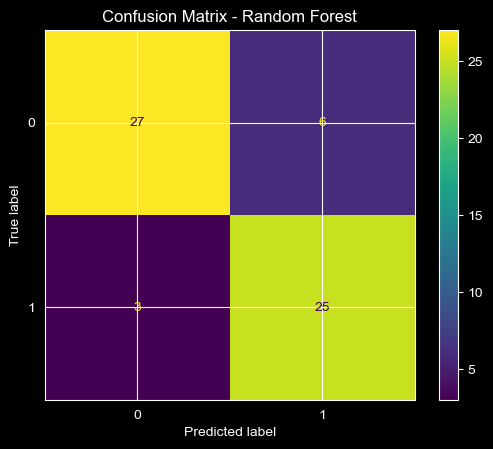

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_y_pred)

plt.title("Confusion Matrix - Random Forest")
plt.show()

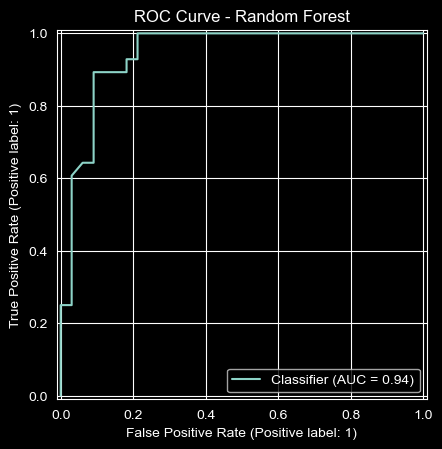

In [46]:
RocCurveDisplay.from_predictions(y_test, rf_y_proba)

plt.title("ROC Curve - Random Forest")
plt.show()

## Random Forest Results

The Random Forest model achieved strong predictive performance overall, but did not significantly outperform the Logistic Regression baseline.

Compared to Logistic Regression, the Random Forest produced slightly more false positives and false negatives on the test set.

In particular, the number of false negatives increased slightly, which is an important consideration in a healthcare setting where failing to identify diseased patients may have significant consequences.

These results suggest that the relationships within the dataset may already be well captured by a relatively simple linear model such as Logistic Regression.

Possible explanations include:
- the relatively small size of the dataset,
- the presence of strong linear predictive signals,
- and limited non-linear complexity within the feature space.

Overall, the Random Forest confirms the predictive relevance of the identified clinical variables, but increased model complexity does not appear to provide substantial benefits in this case.

# XGBoost Model

We now evaluate XGBoost, a gradient boosting algorithm widely used for structured and tabular machine learning tasks.

Unlike Random Forests, XGBoost builds trees sequentially, with each new tree attempting to correct the errors made by previous ones. This allows the model to capture more complex non-linear relationships and feature interactions.

The objective is to determine whether additional predictive structure can be extracted beyond what is captured by simpler models such as Logistic Regression.

## Importing the model

In [47]:
from xgboost import XGBClassifier

## Building the XGBoost Pipeline

In [48]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

## Cross-validated evaluation

In [49]:
xgb_cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [50]:
print("XGBoost Cross-Validation Results:\n")

for metric in scoring:
    scores = xgb_cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

XGBoost Cross-Validation Results:

accuracy: 0.793 ± 0.029
precision: 0.781 ± 0.054
recall: 0.774 ± 0.065
f1: 0.774 ± 0.030
roc_auc: 0.867 ± 0.029


## Fitting the model on the full training dataset

In [51]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Prediction on the test set

In [52]:
xgb_y_pred = xgb_model.predict(X_test)
xgb_y_proba = xgb_model.predict_proba(X_test)[:, 1]

## Evaluation on the test set

In [53]:
print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [54]:
xgb_roc_auc = roc_auc_score(y_test, xgb_y_proba)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.3f}")

XGBoost ROC-AUC: 0.946


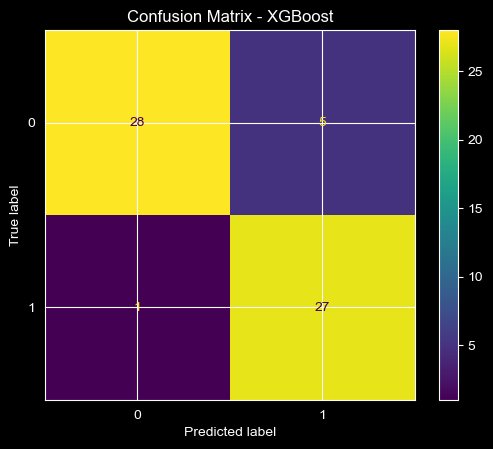

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, xgb_y_pred)

plt.title("Confusion Matrix - XGBoost")
plt.show()

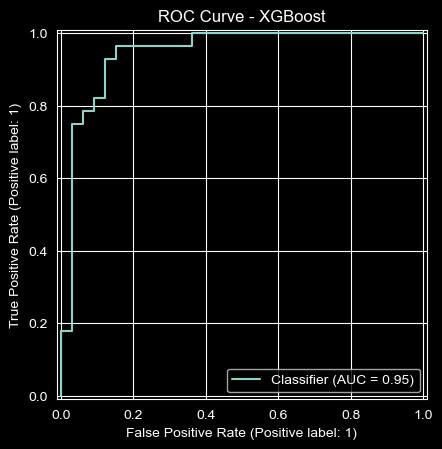

In [56]:
RocCurveDisplay.from_predictions(y_test, xgb_y_proba)

plt.title("ROC Curve - XGBoost")
plt.show()

# Model Comparison

We now compare the performance of the evaluated models across multiple metrics, including:
- accuracy,
- recall,
- F1-score,
- ROC-AUC,
- and interpretability considerations.

The objective is not only to identify the highest-performing model, but also to analyze the tradeoffs between predictive performance, model complexity, and clinical interpretability.

## Comparison table

In [57]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        0.89,
        0.85,
        0.90
    ],

    "Recall (Class 1)": [
        0.93,
        0.81,
        0.96
    ],

    "F1-score": [
        0.88,
        0.85,
        0.90
    ],

    "ROC-AUC": [
        0.97,
        0.94,
        0.95
    ],

    "Interpretability": [
        "High",
        "Medium",
        "Lower"
    ]
})

In [58]:
comparison_df.style.highlight_max(
    subset=["Accuracy", "Recall (Class 1)", "F1-score", "ROC-AUC"],
    axis=0
)

,Model,Accuracy,Recall (Class 1),F1-score,ROC-AUC,Interpretability
0,Logistic Regression,0.890000,0.930000,0.880000,0.970000,High
1,Random Forest,0.850000,0.810000,0.850000,0.940000,Medium
2,XGBoost,0.900000,0.960000,0.900000,0.950000,Lower


## Comparative Analysis

The three evaluated models all achieved strong predictive performance, confirming the presence of meaningful predictive structure within the dataset.

### Logistic Regression

Logistic Regression achieved remarkably strong performance despite its relative simplicity. The model obtained the highest ROC-AUC score, suggesting excellent global class separability and well-calibrated probability rankings.

Its high interpretability also makes it particularly attractive in healthcare contexts, where transparency and clinical explainability are important considerations.

---

### Random Forest

The Random Forest model successfully captured non-linear relationships within the data but did not significantly outperform the Logistic Regression baseline.

This suggests that the dataset may already be largely separable using relatively simple linear relationships, or that the dataset size limits the benefits of more complex ensemble methods.

---

### XGBoost

XGBoost achieved the strongest overall classification performance, particularly in terms of recall for patients with heart disease.

The model reduced false negatives to a single case on the test set, which is highly relevant in medical applications where failing to identify diseased patients may have serious consequences.

These results suggest that XGBoost captures additional non-linear feature interactions not fully modeled by Logistic Regression.

However, this improved performance comes at the cost of increased model complexity and reduced interpretability.

---

### Conclusion

Although Logistic Regression achieved the highest ROC-AUC score (0.97), XGBoost was selected as the final model because it provided the best balance between accuracy, recall, and F1-score. In the context of heart disease prediction, recall is particularly important because failing to identify a patient with heart disease may have serious consequences. The XGBoost model achieved the highest recall (96%), indicating a superior ability to detect patients at risk.

# Hyperparameter Optimization of the XGBoost Model

The initial evaluation of several machine learning models identified XGBoost as the most promising candidate for the heart disease prediction task. While the model already demonstrated strong predictive performance using its default configuration, its effectiveness can often be improved through careful tuning of its hyperparameters.

Hyperparameters control various aspects of the learning process, such as the complexity of the trees, the learning rate, and the degree of regularization applied during training. Selecting appropriate values for these parameters is crucial for achieving a good balance between underfitting and overfitting, ultimately improving the model's ability to generalize to unseen data.

In this section, a hyperparameter optimization procedure is performed using **Randomized Search Cross-Validation**. This approach explores different combinations of hyperparameters while evaluating model performance through stratified cross-validation. Compared to an exhaustive grid search, randomized search allows a broader exploration of the parameter space while remaining computationally efficient.

The optimization focuses on parameters known to have a significant impact on XGBoost performance, including:

- Number of boosting rounds (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Learning rate (`learning_rate`)
- Subsampling ratio (`subsample`)
- Feature sampling ratio (`colsample_bytree`)
- Minimum child weight (`min_child_weight`)
- Regularization parameters (`gamma`, `reg_alpha`, `reg_lambda`)

The objective is to identify the hyperparameter configuration that maximizes predictive performance while maintaining strong generalization capabilities. The optimized model will then be evaluated on the test set and used for the subsequent explainability analysis.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [60]:
param_dist = {
    "classifier__n_estimators": [50, 100, 200, 300],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
    "classifier__reg_alpha": [0, 0.01, 0.1],
    "classifier__reg_lambda": [1, 2, 5]
}

## ROC-AUC optimization

In [61]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [2, 3, ...], ...}"
,n_iter,50
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [62]:
best_xgb_pipeline = xgb_search.best_estimator_

print("Best parameters:")
print(xgb_search.best_params_)

print("Best CV ROC-AUC:")
print(xgb_search.best_score_)

Best parameters:
{'classifier__subsample': 0.7, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0.1, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.7}
Best CV ROC-AUC:
0.8995889778498475


In [63]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_xgb_pipeline.predict(X_test)
y_proba = best_xgb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61

Test ROC-AUC: 0.9458874458874458


## Recall optimization

In [64]:
xgb_search_recall = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search_recall.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [2, 3, ...], ...}"
,n_iter,50
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## F1 score Optimization

In [65]:
xgb_search_f1 = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search_f1.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [2, 3, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## Evaluation

In [66]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "XGBoost tuned ROC-AUC": xgb_search.best_estimator_,
    "XGBoost tuned Recall": xgb_search_recall.best_estimator_,
    "XGBoost tuned F1": xgb_search_f1.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("\n", name)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


 XGBoost tuned ROC-AUC
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61

ROC-AUC: 0.9458874458874458

 XGBoost tuned Recall
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

ROC-AUC: 0.9545454545454546

 XGBoost tuned F1
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   mac

Among the three optimization strategies investigated, the model optimized for recall achieved the best overall performance on the test set. Although the ROC-AUC-optimized model was expected to maximize discriminative ability, the recall-optimized model achieved higher recall, F1-score, accuracy, and ROC-AUC simultaneously.

Given the healthcare context of the problem, where failing to identify a patient with heart disease may have serious consequences, the recall-optimized XGBoost model was selected as the final model for subsequent explainability analyses.

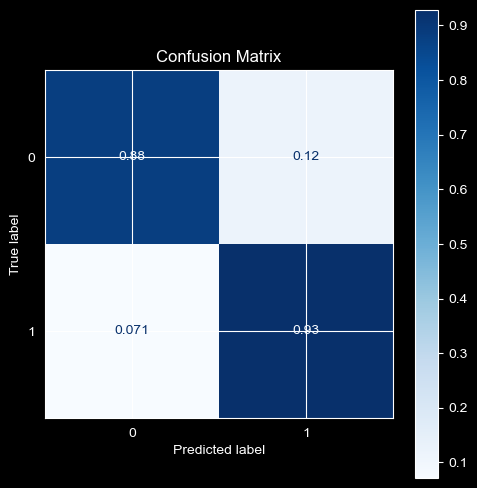

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_xgb_pipeline = xgb_search_recall.best_estimator_

y_pred = best_xgb_pipeline.predict(X_test)

fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize='true',
    cmap="Blues",
    ax=ax
)

ax.set_title("Confusion Matrix")

plt.tight_layout()

plt.show()


plt.close()

# Explainable AI with SHAP

XGBoost achieved the best operational performance, especially in terms of recall for patients with heart disease.

However, because XGBoost is a more complex non-linear model, we use SHAP to better understand how different features contribute to its predictions.

The goal is to evaluate whether the model relies on clinically meaningful patterns and to improve interpretability.

## Global Explainability with SHAP

While evaluating a model's predictive performance is essential, understanding *why* the model makes its predictions is equally important, particularly in healthcare applications where transparency and trust are critical. Explainability techniques help reveal the reasoning behind a model's decisions and ensure that predictions are based on medically meaningful factors rather than spurious correlations.

To achieve this, we use **SHAP (SHapley Additive exPlanations)**, a game-theoretic explainability framework that quantifies the contribution of each feature to a prediction. Unlike traditional feature importance measures, SHAP provides both the magnitude and direction of a feature's impact on the model's output.

The objective of this section is to perform a **global explainability analysis** of the final XGBoost model. By analyzing SHAP values across the entire test dataset, we can identify the features that have the greatest influence on heart disease prediction and assess whether the learned relationships are consistent with established medical knowledge.

The analysis begins with a **SHAP summary plot**, which offers a global view of feature importance and illustrates how different feature values affect the model's predictions. This visualization helps answer several key questions:

- Which features are the most influential in predicting heart disease?
- How do high and low feature values impact the model's predictions?
- Are the identified patterns consistent with known cardiovascular risk factors?

This global analysis provides an overall understanding of the model's behavior before moving on to **local explainability**, where individual patient predictions will be examined in greater detail.

In [68]:
import shap
import matplotlib.pyplot as plt

C:\Users\salah\anaconda3\envs\masters_application\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [69]:
best_xgb_pipeline = xgb_search_recall.best_estimator_

preprocessor = best_xgb_pipeline.named_steps["preprocessor"]
best_xgb = best_xgb_pipeline.named_steps["classifier"]

In [70]:
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [71]:
ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]

for col, cats in zip(categorical_features, ohe.categories_):
    print(f"{col}: {cats}")

sex: [0. 1.]
cp: [1. 2. 3. 4.]
fbs: [0. 1.]
restecg: [0. 1. 2.]
exang: [0. 1.]
slope: [1. 2. 3.]
ca: [0. 1. 2. 3.]
thal: [3. 6. 7.]


In [72]:
feature_rename = {
    "cat__sex_0.0": "Sex = Female",
    "cat__sex_1.0": "Sex = Male",

    "cat__cp_1.0": "Chest pain = Typical angina",
    "cat__cp_2.0": "Chest pain = Atypical angina",
    "cat__cp_3.0": "Chest pain = Non-anginal pain",
    "cat__cp_4.0": "Chest pain = Asymptomatic",

    "cat__fbs_0.0": "Fasting blood sugar not above 120 mg/dl",
    "cat__fbs_1.0": "Fasting blood sugar above 120 mg/dl",

    "cat__restecg_0.0": "Resting ECG = Normal",
    "cat__restecg_1.0": "Resting ECG = ST-T abnormality",
    "cat__restecg_2.0": "Resting ECG = LV hypertrophy",

    "cat__exang_0.0": "Exercise angina = No",
    "cat__exang_1.0": "Exercise angina = Yes",

    "cat__slope_1.0": "Slope = Upsloping",
    "cat__slope_2.0": "Slope = Flat",
    "cat__slope_3.0": "Slope = Downsloping",

    "cat__ca_0.0": "Major vessels = 0",
    "cat__ca_1.0": "Major vessels = 1",
    "cat__ca_2.0": "Major vessels = 2",
    "cat__ca_3.0": "Major vessels = 3",

    "cat__thal_3.0": "Thalassemia = Normal",
    "cat__thal_6.0": "Thalassemia = Fixed defect",
    "cat__thal_7.0": "Thalassemia = Reversible defect",

    "num__age": "Age",
    "num__trestbps": "Resting blood pressure",
    "num__chol": "Cholesterol",
    "num__thalach": "Maximum heart rate",
    "num__oldpeak": "ST depression"
}

In [73]:
X_test_shap = X_test_processed_df.rename(columns=feature_rename)


In [74]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test_shap)


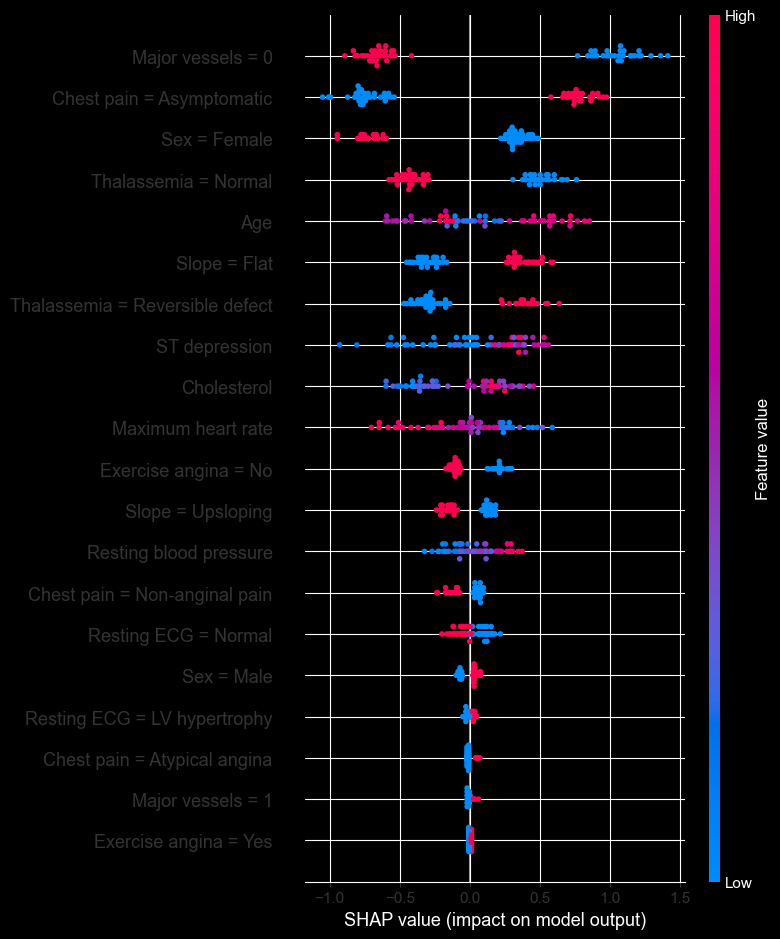

In [75]:
shap_values.feature_names = list(X_test_shap.columns)

shap.summary_plot(shap_values, X_test_shap)

The SHAP summary plot reveals that the model primarily relies on clinically relevant cardiovascular indicators. The most influential features include the number of major vessels, chest pain type, age, thalassemia status, ST depression, and maximum heart rate. These variables are widely recognized as important risk factors for cardiovascular disease, suggesting that the model has learned medically plausible relationships rather than relying on spurious correlations. Additionally, the relatively lower importance of cholesterol compared to vessel obstruction and chest pain highlights the multifactorial nature of heart disease prediction in the Cleveland dataset.

In [76]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(10)

,Feature,Mean |SHAP|
0,Major vessels = 0,0.850126
1,Chest pain = Asymptomatic,0.764612
2,Sex = Female,0.467026
3,Thalassemia = Normal,0.465546
4,Age,0.359790
5,Slope = Flat,0.346289
6,Thalassemia = Reversible defect,0.335458
7,ST depression,0.300769
8,Cholesterol,0.282256
9,Maximum heart rate,0.241592


In [77]:
top10_shap = shap_importance.head(10)

top10_shap

,Feature,Mean |SHAP|
0,Major vessels = 0,0.850126
1,Chest pain = Asymptomatic,0.764612
2,Sex = Female,0.467026
3,Thalassemia = Normal,0.465546
4,Age,0.359790
5,Slope = Flat,0.346289
6,Thalassemia = Reversible defect,0.335458
7,ST depression,0.300769
8,Cholesterol,0.282256
9,Maximum heart rate,0.241592


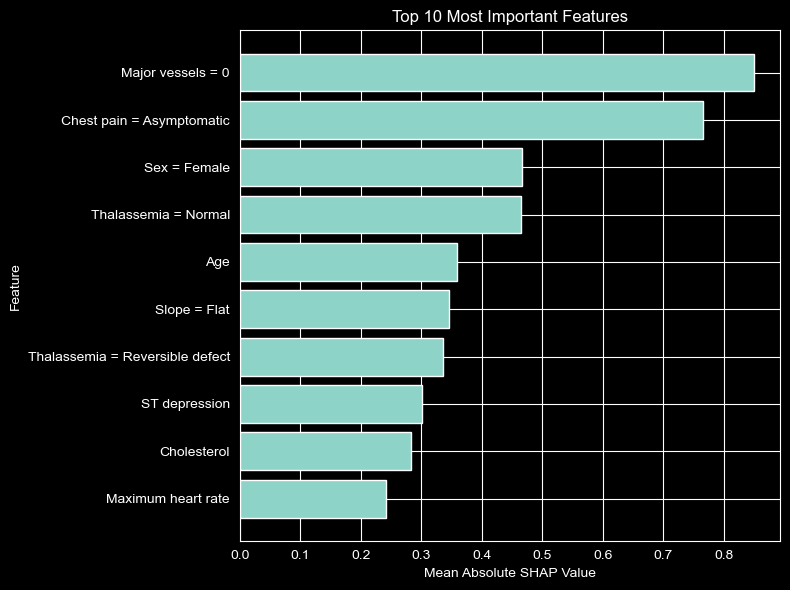

In [78]:
import matplotlib.pyplot as plt

top10_shap = shap_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(
    top10_shap["Feature"][::-1],
    top10_shap["Mean |SHAP|"][::-1]
)
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")
plt.tight_layout()
plt.show()

The quantitative SHAP analysis confirms the findings of the summary plot. The absence of major vessel obstruction emerged as the most influential feature, followed by asymptomatic chest pain, sex, thalassemia status, and age. Interestingly, variables directly related to cardiovascular function and clinical symptoms were ranked above traditional risk factors such as cholesterol. This suggests that the model primarily relies on medically meaningful indicators that are closely associated with the underlying disease process. Overall, the consistency between the identified features and established cardiovascular knowledge increases confidence in the validity and interpretability of the model.

### Interpretation of the SHAP Analysis

The SHAP analysis indicates that the XGBoost model primarily relies on clinically relevant cardiovascular indicators when predicting heart disease. The most influential features include the number of major vessels, chest pain type, sex, thalassemia status, age, ST depression, and maximum heart rate.

The absence of major vessel obstruction emerged as the strongest predictor, followed by asymptomatic chest pain, both of which are closely associated with cardiovascular disease. Age and ST depression also showed a positive relationship with the predicted risk of heart disease, while higher maximum heart rates tended to decrease the predicted risk.

Interestingly, traditional risk factors such as cholesterol were less influential than direct indicators of cardiovascular function and clinical symptoms. Overall, the consistency between the model's most important features and established medical knowledge suggests that the model has learned meaningful patterns rather than relying on spurious correlations, increasing confidence in both its predictive performance and interpretability.

## Local Explainability with SHAP

While global explainability provides insights into the overall behavior of the model, it does not explain why a specific prediction was made for an individual patient. In healthcare applications, understanding the reasoning behind individual predictions is particularly important, as clinical decisions are ultimately made at the patient level.

To address this, a local explainability analysis is performed using SHAP waterfall plots. These visualizations decompose a single prediction into the contributions of each feature, showing how individual characteristics push the model toward or away from predicting heart disease. Starting from a baseline prediction, each feature contributes positively or negatively to the final prediction according to its SHAP value.

In this section, representative patient cases are analyzed to better understand the model's decision-making process. Particular attention is given to misclassified patients, especially false negatives, as these correspond to cases where a patient with heart disease was incorrectly classified as healthy. Examining such cases helps identify the factors that contributed to the model's errors and provides valuable insights into its limitations.

The objective of this analysis is to complement the global interpretation by answering the question:

> **Why did the model make this prediction for this specific patient?**

By examining individual predictions, we gain a deeper understanding of the model's behavior and its potential strengths and weaknesses in a healthcare context.

In [79]:
y_pred = best_xgb_pipeline.predict(X_test)

In [80]:
import numpy as np

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]
tn_idx = np.where((y_test == 0) & (y_pred == 0))[0][0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

print("True Positive:", tp_idx)
print("True Negative:", tn_idx)
print("False Positive:", fp_idx)
print("False Negative:", fn_idx)

True Positive: 8
True Negative: 0
False Positive: 1
False Negative: 24


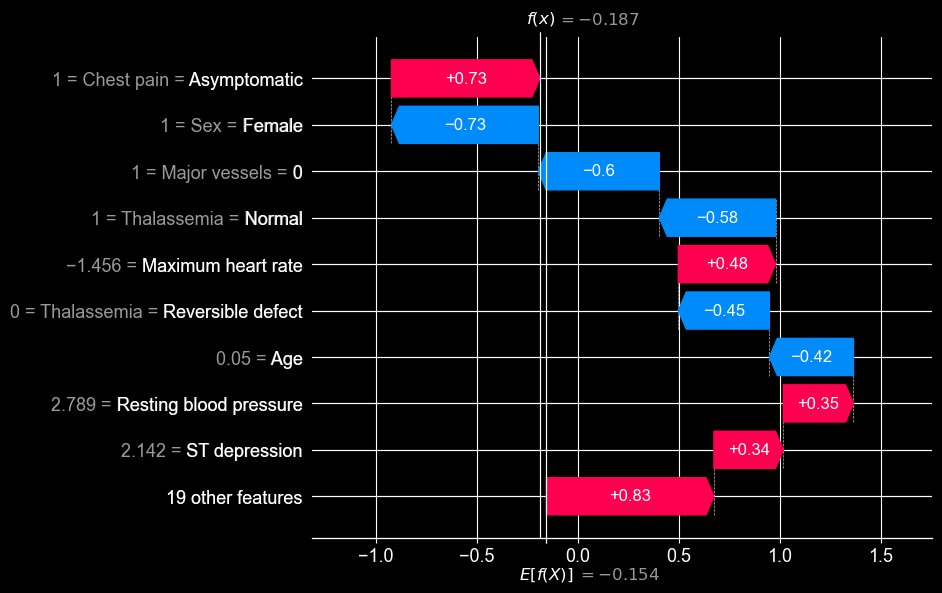

In [81]:
shap.plots.waterfall(shap_values[fn_idx])

In [82]:
X_test.iloc[fn_idx]

age          55.0
sex           0.0
cp            4.0
trestbps    180.0
chol        327.0
fbs           0.0
restecg       1.0
thalach     117.0
exang         1.0
oldpeak       3.4
slope         2.0
ca            0.0
thal          3.0
Name: 231, dtype: float64

### False Negative Case Analysis

This patient was diagnosed with heart disease but was incorrectly classified as healthy by the model. The SHAP waterfall plot reveals a conflict between several strong risk factors and several protective indicators.

Features such as asymptomatic chest pain, elevated resting blood pressure, reduced maximum heart rate, and increased ST depression pushed the prediction toward heart disease. However, the patient was female, presented no major vessel obstruction, and had normal thalassemia results, all of which strongly decreased the predicted risk.

The model ultimately assigned greater importance to the absence of vessel obstruction and normal thalassemia findings than to the patient's clinical symptoms. As a result, the prediction was shifted toward the healthy class, producing a false negative. This example highlights one of the limitations of the model and illustrates how local explainability can help identify the factors responsible for misclassifications.

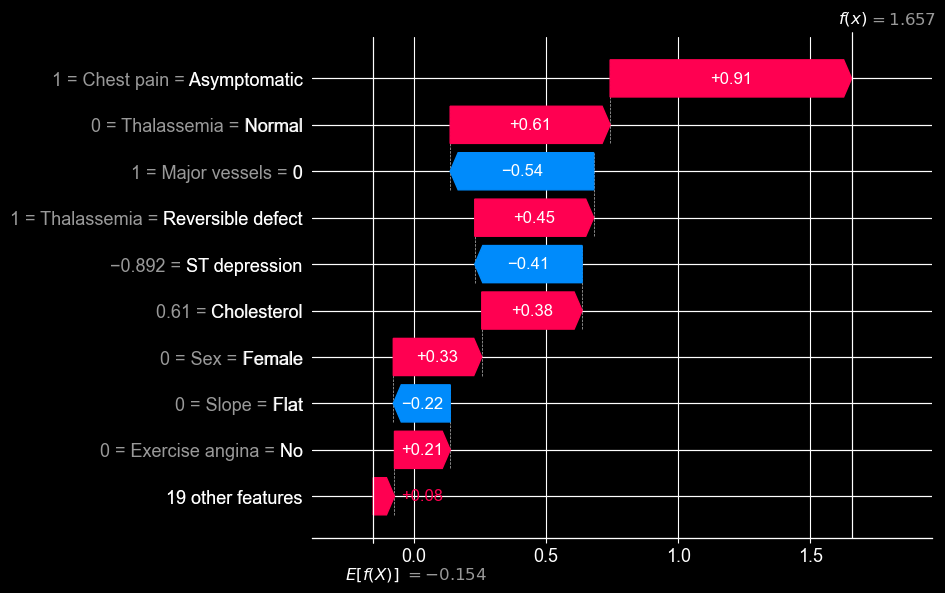

In [83]:
shap.plots.waterfall(shap_values[tp_idx])

In [84]:
X_test.iloc[tp_idx]

age          35.0
sex           1.0
cp            4.0
trestbps    126.0
chol        282.0
fbs           0.0
restecg       2.0
thalach     156.0
exang         1.0
oldpeak       0.0
slope         1.0
ca            0.0
thal          7.0
Name: 168, dtype: float64

### True Positive Case Analysis

This patient was correctly classified as having heart disease. Although the patient is relatively young and presents no major vessel obstruction, the SHAP waterfall plot shows that several clinically relevant risk factors strongly influenced the prediction.

The most important contributor was asymptomatic chest pain, which produced the largest positive SHAP value. Additional risk factors included a reversible thalassemia defect, elevated cholesterol levels, and the presence of exercise-induced angina. These features collectively pushed the prediction toward the positive class.

Conversely, the absence of major vessel obstruction and ST depression reduced the predicted risk. However, their protective effects were insufficient to offset the strong evidence provided by the patient's symptoms and thalassemia findings. As a result, the model correctly classified the patient as having heart disease.

This example illustrates the model's ability to identify disease even when some traditional indicators appear reassuring, highlighting the importance of combining multiple clinical variables when assessing cardiovascular risk.

### Comparison of Local Explanations

Comparing the false negative and true positive cases provides valuable insights into the decision-making process of the XGBoost model. In both cases, asymptomatic chest pain was identified as a strong indicator of heart disease, reflecting its high importance in the global SHAP analysis. However, the final predictions differed because the model evaluated the overall balance of evidence rather than relying on a single feature.

In the false negative case, several risk factors such as asymptomatic chest pain, elevated resting blood pressure, and increased ST depression pushed the prediction toward heart disease. Nevertheless, these signals were outweighed by the absence of major vessel obstruction, normal thalassemia findings, and female sex, ultimately leading the model to predict the healthy class.

In contrast, the true positive case combined asymptomatic chest pain with additional risk factors, including a reversible thalassemia defect, elevated cholesterol levels, and exercise-induced angina. Although the patient also presented no major vessel obstruction, the accumulation of these indicators was sufficient to strongly shift the prediction toward heart disease.

These examples suggest that major vessel obstruction and thalassemia status act as particularly influential features within the model. The absence of vessel obstruction and normal thalassemia findings provide strong evidence against heart disease, while abnormal thalassemia results substantially increase predicted risk. However, the model does not rely exclusively on these variables. Instead, it combines multiple clinical indicators to estimate cardiovascular risk, allowing strong symptom profiles to overcome otherwise protective factors.

More broadly, the comparison highlights the nonlinear nature of the XGBoost model. Rather than evaluating each feature independently, the model captures interactions between multiple risk factors and bases its predictions on their combined effect. This behavior is consistent with clinical practice, where heart disease diagnosis typically depends on the presence of several complementary indicators rather than any single measurement.

# Fairness Analysis

In healthcare applications, predictive performance alone is not sufficient to assess the quality of a machine learning model. It is also important to ensure that the model performs consistently across different demographic groups. A model that achieves strong overall performance may still exhibit disparities in error rates between subpopulations, potentially leading to unequal outcomes.

The SHAP analysis revealed that sex was among the most influential features used by the XGBoost model. This observation motivates a fairness analysis to investigate whether the model behaves similarly for male and female patients.

To evaluate fairness, the model's performance is assessed separately for each sex. Metrics such as precision, recall, F1-score, and confusion matrices are compared across groups. Particular attention is paid to recall, as failing to identify patients with heart disease (false negatives) may have serious consequences in a clinical setting.

The objective of this analysis is not to remove differences between groups, but rather to identify potential disparities in predictive performance and assess whether the model's decisions remain equitable across demographic subpopulations.

## Splitting the test set by sex

In [85]:
male_mask = X_test["sex"] == 1
female_mask = X_test["sex"] == 0

## Evaluation for each subgroup

In [86]:
from sklearn.metrics import classification_report

print("Male Patients")
print(
    classification_report(
        y_test[male_mask],
        y_pred[male_mask]
    )
)

print("\nFemale Patients")
print(
    classification_report(
        y_test[female_mask],
        y_pred[female_mask]
    )
)

Male Patients
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.83      0.95      0.89        21

    accuracy                           0.88        41
   macro avg       0.89      0.88      0.88        41
weighted avg       0.89      0.88      0.88        41


Female Patients
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.86      0.92         7

    accuracy                           0.95        20
   macro avg       0.96      0.93      0.94        20
weighted avg       0.95      0.95      0.95        20



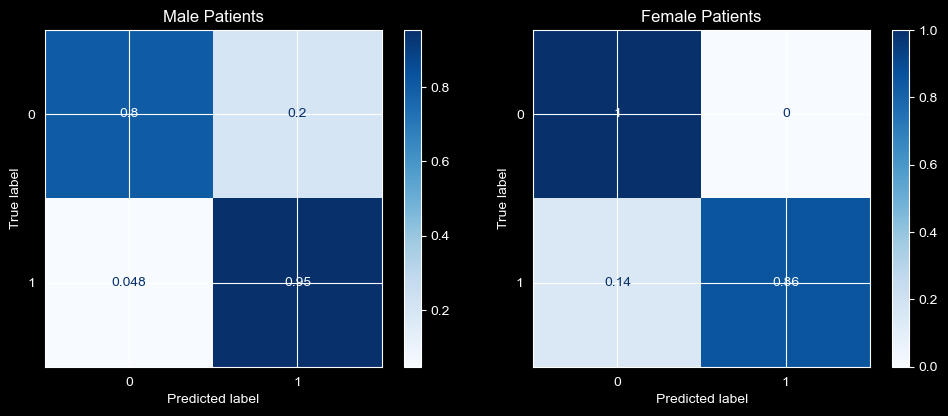

In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test[male_mask],
    y_pred[male_mask],
    normalize="true",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Male Patients")

ConfusionMatrixDisplay.from_predictions(
    y_test[female_mask],
    y_pred[female_mask],
    normalize="true",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Female Patients")

plt.tight_layout()
plt.show()

## Fairness Analysis Results

The subgroup analysis revealed relatively similar predictive performance across male and female patients. The model achieved an accuracy of 88% for male patients and 95% for female patients, indicating strong performance for both groups.

When focusing on the positive class (heart disease), the recall was slightly higher for male patients (95%) than for female patients (86%). This suggests that the model was somewhat more likely to miss female patients with heart disease. However, the precision for female patients reached 100%, meaning that no healthy female patients were incorrectly classified as diseased.

The confusion matrices indicate that the model produced more false positives among male patients and more false negatives among female patients. Nevertheless, these differences should be interpreted with caution due to the limited size of the female subgroup, which contained only seven positive cases. In such a small sample, a single misclassification can substantially affect the reported metrics.

Overall, the results do not provide strong evidence of severe demographic bias. While minor differences in error rates exist between male and female patients, the model maintains good predictive performance across both groups. Further evaluation on a larger and more balanced dataset would be required to draw stronger conclusions regarding fairness.

# Limitations

Although the proposed XGBoost model achieved strong predictive performance and demonstrated clinically meaningful decision-making patterns, several limitations should be acknowledged.

First, the Cleveland Heart Disease dataset is relatively small, containing only a few hundred patient records. As a result, performance estimates may be sensitive to the particular train-test split used, and the model's generalization ability may be difficult to assess reliably. In addition, the limited sample size restricts the robustness of subgroup analyses, particularly the fairness evaluation across male and female patients.

Second, the dataset originates from a specific clinical context and may not be representative of broader patient populations. Consequently, the model's performance on patients from different hospitals, regions, or demographic groups remains unknown. External validation on independent datasets would be required before considering real-world deployment.

Third, while the SHAP analysis suggests that the model relies on medically plausible features, explainability methods provide insights into model behavior rather than causal relationships. The identified feature importance should therefore be interpreted as predictive rather than causal evidence.

Finally, the project focuses exclusively on tabular clinical data. Modern healthcare applications increasingly combine multiple sources of information, including medical imaging, physiological signals, electronic health records, and genomic data. Integrating such heterogeneous data sources could potentially improve predictive performance and provide a more comprehensive assessment of patient risk.

# Future Work

Several extensions could further improve this work:

- Perform a more extensive fairness analysis using dedicated fairness metrics such as demographic parity, equal opportunity, and equalized odds.
- Investigate calibration techniques to ensure that predicted probabilities accurately reflect observed risk.
- Evaluate the model on larger and more diverse cardiovascular datasets to assess generalization performance.
- Explore ensemble approaches and advanced gradient boosting techniques.
- Develop anomaly detection approaches based on autoencoders to identify atypical patient profiles and support early disease detection.
- Investigate explainable and fair machine learning methods specifically designed for healthcare applications.

These directions would contribute to building more robust, transparent, and equitable machine learning systems for cardiovascular risk prediction.

# Conclusion

In this project, several machine learning models were developed and evaluated for the prediction of heart disease using the Cleveland Heart Disease dataset. After comparing Logistic Regression, Random Forest, and XGBoost models, XGBoost was selected as the final model due to its strong balance between recall, F1-score, and overall predictive performance. Hyperparameter optimization was subsequently performed to further improve model performance.

To better understand the model's decision-making process, both global and local explainability analyses were conducted using SHAP. The global analysis revealed that the model primarily relied on clinically relevant features such as the number of major vessels, chest pain type, thalassemia status, age, and ST depression. Local explanations demonstrated how individual risk factors interact to influence predictions and highlighted the importance of considering multiple clinical indicators simultaneously when assessing cardiovascular risk.

A fairness analysis was also performed to evaluate model performance across male and female patients. While minor differences in recall and error rates were observed, no strong evidence of severe demographic bias was identified. However, the limited size of the dataset suggests that further evaluation on larger and more diverse populations would be necessary before drawing definitive conclusions.

Overall, the results demonstrate that machine learning models can effectively identify patterns associated with heart disease while remaining interpretable through modern explainability techniques. By combining predictive performance, explainability, and fairness considerations, this project illustrates the potential of responsible machine learning approaches in healthcare applications.

## Key Takeaways

- XGBoost achieved the best balance between recall and overall predictive performance.
- SHAP analysis showed that the model relies primarily on clinically meaningful cardiovascular indicators.
- Local explanations revealed how multiple risk factors interact to influence predictions.
- Fairness analysis showed only minor differences between male and female patients.
- Explainability and fairness analyses increased confidence in the model's predictions.

## Saving the Final Model

To facilitate future use and reproducibility, the final optimized XGBoost pipeline is saved using Joblib. Saving the complete pipeline ensures that both the preprocessing steps and the trained model can be reused without retraining.

In [92]:
import joblib

joblib.dump(
    best_xgb_pipeline,
    "../models/heart_disease_xgb_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
